## Data Loading
importing libraries required for data loading. inspection and basic visualisation


In [2]:
import pandas as pd
import numpy as np

df=pd.read_csv("owid-energy-data.csv")
df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [3]:
df.shape

(23195, 130)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23195 entries, 0 to 23194
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.0+ MB


In [6]:
df["country"].unique()

array(['ASEAN (Ember)', 'Afghanistan', 'Africa', 'Africa (EI)',
       'Africa (EIA)', 'Africa (Ember)', 'Africa (Shift)', 'Albania',
       'Algeria', 'American Samoa', 'Angola', 'Antarctica',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Asia',
       'Asia (Ember)', 'Asia Pacific (EI)', 'Asia and Oceania (EIA)',
       'Asia and Oceania (Shift)', 'Australia',
       'Australia and New Zealand (EIA)', 'Austria', 'Azerbaijan',
       'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus',
       'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'CIS (EI)', 'Cambodia', 'Cameroon', 'Canada',
       'Cape Verde', 'Cayman Islands', 'Central African Republic',
       'Central America (EI)', 'Central and South America (EIA)',
       'Central and South America (Shift)', 'Chad', 'Chile', 'China',
       'Colombia', 'Co

## Initial Data Inspection
The dataset contains energy data for many countries starting from 1900. At first look, basic economic data is mostly available, but many energy variables have missing values, especially in early years.

In [7]:
df_ie_fr=df[df["country"].isin(["Ireland", "France"])]
df_ie_fr.shape

(250, 130)

## Country Selection
Irelandwas chosen as the main country, as required by the assignment. France was selected for comparison because it is a larger EU country with a different energy structure.

In [8]:
df_ie_fr["country"].unique()

array(['France', 'Ireland'], dtype=object)

In [9]:
df_ie_fr["year"].min(), df_ie_fr["year"].max()

(1900, 2024)

In [13]:
missing_pct = (df_ie_fr.isnull().sum() / len(df_ie_fr)) * 100
missing_pct.sort_values()

country                      0.0
year                         0.0
iso_code                     0.0
coal_prod_per_capita         6.4
coal_production              6.4
                            ... 
nuclear_cons_change_pct     76.4
biofuel_cons_change_pct     79.6
carbon_intensity_elec       80.0
greenhouse_gas_emissions    80.0
solar_cons_change_pct       81.2
Length: 130, dtype: float64

## Handling Missing Data
Some energy data is missing in early years, especially before 1970. this is common in old datasets To keep the analysis clear and reliable, data before 1970 is not used.

In [14]:
df_ie_fr.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='object', length=130)

## To make the data simple, we chose important columns about energy for Ireland and France and put them into a new DataFrame

In [15]:
cols = ["country", "year", "population", "gdp", "primary_energy_consumption", "renewables_share_energy", "wind_share_energy"]

df_energy = df_ie_fr[cols]
df_energy.head()

,country,year,population,gdp,primary_energy_consumption,renewables_share_energy,wind_share_energy
7625,France,1900,40019136.0,1.861012e+11,NaN,NaN,NaN
7626,France,1901,40067484.0,1.830832e+11,NaN,NaN,NaN
7627,France,1902,40116538.0,1.800736e+11,NaN,NaN,NaN
7628,France,1903,40166299.0,1.840672e+11,NaN,NaN,NaN
7629,France,1904,40216118.0,1.854181e+11,NaN,NaN,NaN


In [16]:
df_energy.isnull().sum()

country                         0
year                            0
population                     50
gdp                            24
primary_energy_consumption    130
renewables_share_energy       130
wind_share_energy             130
dtype: int64

In [17]:
df_energy = df_energy[df_energy["year"] > 1970]

## i chosed the countries and variables, and used data after 1970 only, becouse before this date not correct data

In [18]:
df_energy.isnull().sum()

country                       0
year                          0
population                    0
gdp                           4
primary_energy_consumption    0
renewables_share_energy       0
wind_share_energy             0
dtype: int64

In [22]:
df_energy["population"] = df_energy["population"].fillna(df_energy["population"].mean())
df_energy["gdp"] = df_energy["gdp"].fillna(df_energy["gdp"].mean())
df_energy["primary_energy_consumption"] = df_energy["primary_energy_consumption"].fillna(df_energy["primary_energy_consumption"].mean())
df_energy["renewables_share_energy"] = df_energy["renewables_share_energy"].fillna(df_energy["renewables_share_energy"].mean())
df_energy["wind_share_energy"] = df_energy["wind_share_energy"].fillna(df_energy["wind_share_energy"].mean())

df_energy.isnull().sum()

country                       0
year                          0
population                    0
gdp                           0
primary_energy_consumption    0
renewables_share_energy       0
wind_share_energy             0
dtype: int64

## To understand the data i did a simple exploratary analisys. i used scatter plots to se how energy consumpion changes over time in 2 countries

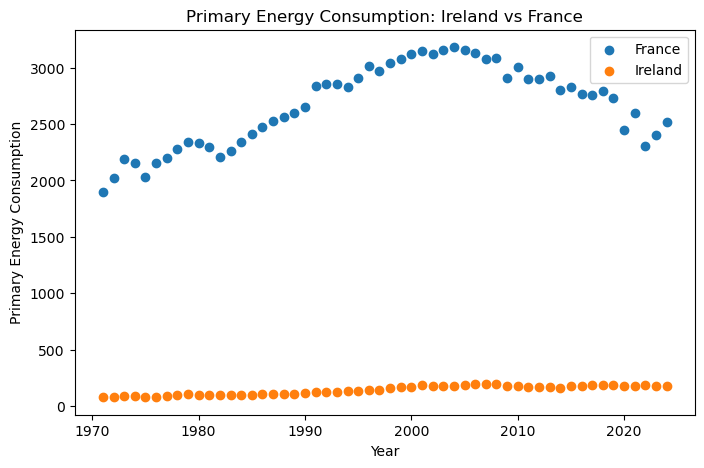

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

df_fr = df_energy[df_energy["country"] == "France"]
df_ie = df_energy[df_energy["country"] == "Ireland"]

plt.figure(figsize=(8,5))
plt.scatter(df_fr["year"], df_fr["primary_energy_consumption"], label="France")
plt.scatter(df_ie["year"], df_ie["primary_energy_consumption"], label="Ireland")
plt.xlabel("Year")
plt.ylabel("Primary Energy Consumption")
plt.title("Primary Energy Consumption: Ireland vs France")
plt.legend()
plt.show()

## The first scatter plot shows a big difference in energy use between Ireland and France
because France uses much more energy, it is hard to see details for both countries on one plot
thats why, i separate them to analyse each country clearly

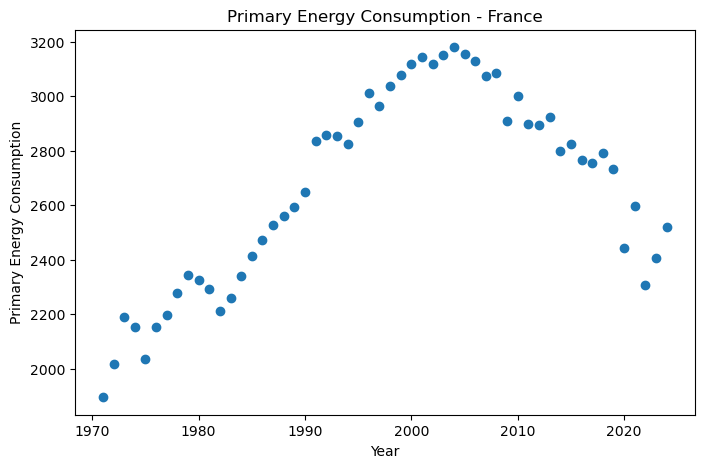

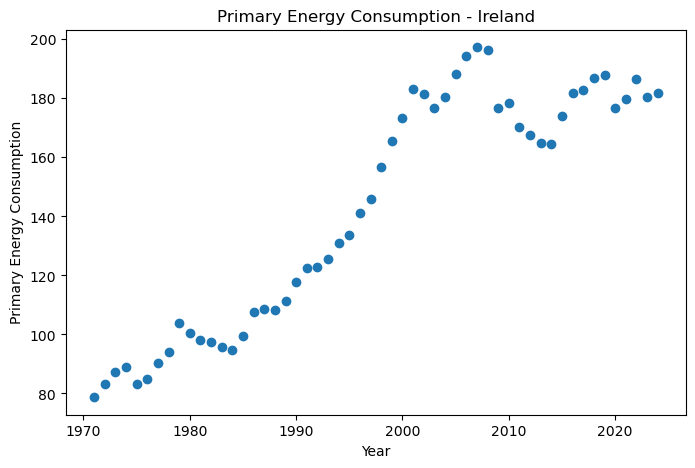

In [35]:
plt.figure(figsize=(8,5))
plt.scatter(
    df_energy[df_energy["country"] == "France"]["year"],
    df_energy[df_energy["country"] == "France"]["primary_energy_consumption"]
)

plt.xlabel("Year")
plt.ylabel("Primary Energy Consumption")
plt.title("Primary Energy Consumption - France")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(
    df_energy[df_energy["country"] == "Ireland"]["year"],
    df_energy[df_energy["country"] == "Ireland"]["primary_energy_consumption"]
)

plt.xlabel("Year")
plt.ylabel("Primary Energy Consumption")
plt.title("Primary Energy Consumption - Ireland")
plt.show()

## Now i show energy consumption for each country separetly and difference becomes clear. France uses much more (above 3000 twh) per year than Ireland (below 200/year), because France has a larger populatuion than ireland, more factories a bigger territory, and more regions that need heating in winter